In [4]:
import itertools
import random
import time
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

**Generate random graph with n nodes and m edges.**

In [5]:
def generate_graph_with_edges(n=20, m=30, seed=42): # Added a default seed
    """
    Generate a random undirected graph with n nodes and exactly m edges.
    """
    if seed is not None:
        random.seed(seed)

    G = nx.Graph()
    G.add_nodes_from(range(n))

    # All possible edges
    all_edges = list(itertools.combinations(range(n), 2))

    # Sample exactly m edges
    if m > len(all_edges):
        raise ValueError(f"Cannot create a graph with {n} nodes and {m} edges. Maximum possible edges is {len(all_edges)}")
    edges = random.sample(all_edges, m)
    G.add_edges_from(edges)

    return G

**Brute Force approach to solve vertex cover**

In [6]:
def is_vertex_cover(G, cover):
    """Check if a given set 'cover' is a valid vertex cover of G"""
    for u, v in G.edges():
        if u not in cover and v not in cover:
            return False
    return True

def brute_force_vertex_cover(G): # took help from gpt to make this function
    """
    Brute force algorithm:
    Check all subsets of vertices to find the minimum vertex cover.
    """
    nodes = list(G.nodes())
    n = len(nodes)
    start_time = time.time()

    for r in range(1, n + 1):
        for subset in itertools.combinations(nodes, r):
            if is_vertex_cover(G, subset):
                end_time = time.time()
                runtime = end_time - start_time
                return len(subset), runtime
    end_time = time.time()
    return n, end_time - start_time   # worst case


**Greedy approximation algorithm to solve vertex cover.**

In [7]:
def maximal_matching(graph):
    matching = set()
    # Create a copy of edges to iterate over, as edges will be removed
    edges = list(graph.edges())
    for u, v in edges:
        # If neither u nor v is already covered by an edge in the matching
        if u not in set(sum(matching, ())) and v not in set(sum(matching, ())):
            matching.add((u, v))
    return matching

def two_fac_vertex_cover(matching):
    vertex_cover = set()
    for u, v in matching:
        vertex_cover.add(u)
        vertex_cover.add(v)
    return vertex_cover

**For n=20 and m=20,40,60,....,180.   
Run the experiment for above input using brute force and greedy.**

In [8]:
def run_experiment(n=20, m_values=range(20, 181, 20)):
    results = []
    for m in m_values:
        print(f"Running for n={n}, m={m}...")
        G = generate_graph_with_edges(n=n, m=m, seed=m)  # seed = m for reproducibility

        # Brute force
        bf_size, bf_time = brute_force_vertex_cover(G)

        # Greedy
        start_time = time.time()
        matching = maximal_matching(G)
        gr_cover = two_fac_vertex_cover(matching)
        end_time = time.time()
        gr_size = len(gr_cover)
        gr_time = end_time - start_time

        # Approximation factor
        approx_factor = gr_size / bf_size if bf_size > 0 else float('inf')

        results.append({
            "n": n,
            "m": m,
            "BruteForce_Size": bf_size,
            "BruteForce_Time": bf_time,
            "Greedy_Size": gr_size,
            "Greedy_Time": gr_time,
            "Approx_Factor": approx_factor
        })
    return pd.DataFrame(results)

**Run and save the results into a csv file.**

In [9]:
df_results = run_experiment(n=20, m_values=range(20, 181, 20))
print(df_results)

# Save to CSV
df_results.to_csv("vertex_cover_results_n20.csv", index=False)

Running for n=20, m=20...
Running for n=20, m=40...
Running for n=20, m=60...
Running for n=20, m=80...
Running for n=20, m=100...
Running for n=20, m=120...
Running for n=20, m=140...
Running for n=20, m=160...
Running for n=20, m=180...
    n    m  BruteForce_Size  BruteForce_Time  Greedy_Size  Greedy_Time  \
0  20   20                8         0.390223           14     0.000084   
1  20   40               11         1.649140           16     0.000084   
2  20   60               13         2.743257           20     0.000163   
3  20   80               13         3.658293           16     0.000118   
4  20  100               15         3.081519           20     0.000135   
5  20  120               16         3.550468           20     0.000175   
6  20  140               16         5.105188           18     0.000175   
7  20  160               17         5.240738           20     0.000185   
8  20  180               18         4.759659           20     0.000345   

   Approx_Factor  
0

**Visualizing the results.**

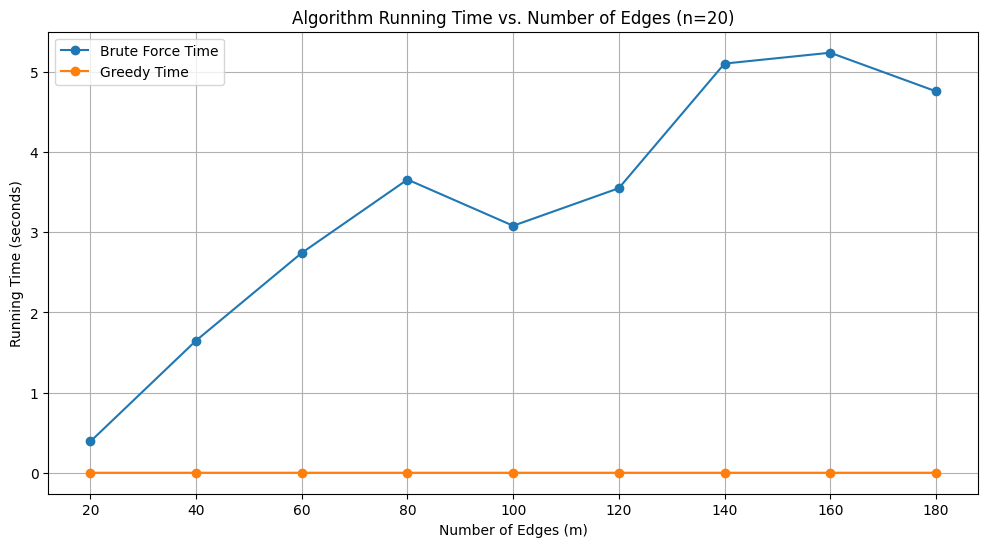

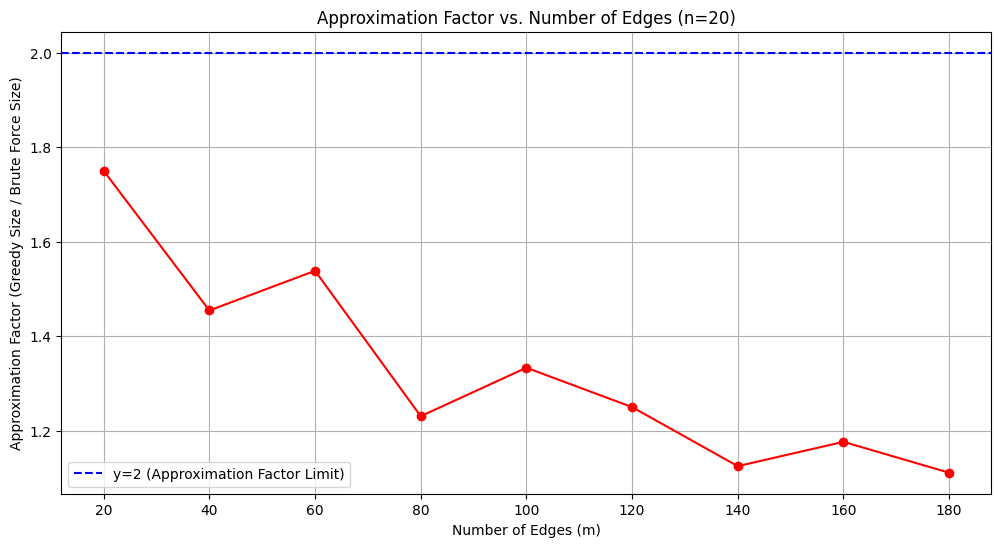

In [10]:
# Plotting the running time
plt.figure(figsize=(12, 6))
plt.plot(df_results['m'], df_results['BruteForce_Time'], marker='o', label='Brute Force Time')
plt.plot(df_results['m'], df_results['Greedy_Time'], marker='o', label='Greedy Time')
plt.xlabel('Number of Edges (m)')
plt.ylabel('Running Time (seconds)')
plt.title('Algorithm Running Time vs. Number of Edges (n=20)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting the approximation factor
plt.figure(figsize=(12, 6))
plt.plot(df_results['m'], df_results['Approx_Factor'], marker='o', color='red')
plt.axhline(y=2, color='blue', linestyle='--', label='y=2 (Approximation Factor Limit)') # Added line at y=2
plt.xlabel('Number of Edges (m)')
plt.ylabel('Approximation Factor (Greedy Size / Brute Force Size)')
plt.title('Approximation Factor vs. Number of Edges (n=20)')
plt.legend() # Added legend to show the new line label
plt.grid(True)
plt.show()